In [ ]:
!pip install understatapi -q

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from understatapi import UnderstatClient
import time

client = UnderstatClient()
plt.rcParams["font.family"] = "DejaVu Sans"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.7/537.7 kB 10.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5/153.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.1/138.1 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
blobfile 3.2.0 requires urllib3>=2,

In [ ]:
# Season key = start year (e.g. "2014" = 2014/15)
champions = {
    "2014": "Chelsea",
    "2015": "Leicester",
    "2016": "Chelsea",
    "2017": "Manchester City",
    "2018": "Manchester City",
    "2019": "Liverpool",
    "2020": "Manchester City",
    "2021": "Manchester City",
    "2022": "Manchester City",
    "2023": "Manchester City",
    "2024": "Liverpool",
}

In [ ]:
# Cell 3 — Fetch all data including full attacking metrics

def fetch_team_season(season, team_name, label):
    players = client.league(league="EPL").get_player_data(season=season)
    rows = []
    for p in players:
        if p.get("team_title") == team_name:
            rows.append({
                "season":      label,
                "team":        team_name,
                "player":      p.get("player_name"),
                "position":    p.get("position", ""),
                "goals":       int(p.get("goals", 0)),
                "xG":          float(p.get("xG", 0)),
                "xA":          float(p.get("xA", 0)),
                "npxG":        float(p.get("npxG", 0)),
                "xGChain":     float(p.get("xGChain", 0)),
                "xGBuildup":   float(p.get("xGBuildup", 0)),
                "shots":       int(p.get("shots", 0)),
                "key_passes":  int(p.get("key_passes", 0)),
                "assists":     int(p.get("assists", 0)),
            })
    time.sleep(2)
    return rows

all_data = []

for season, champion in champions.items():
    label = f"{season}/{str(int(season)+1)[2:]}"
    print(f"Fetching {label} — {champion}...")
    all_data += fetch_team_season(season, champion, label)

print("Fetching Arsenal 2025/26...")
all_data += fetch_team_season("2025", "Arsenal", "2025/26")

df = pd.DataFrame(all_data)
print(f"\nDone. {len(df)} records.")
print(df.columns.tolist())

Fetching 2014/15 — Chelsea...
Fetching 2015/16 — Leicester...
Fetching 2016/17 — Chelsea...
Fetching 2017/18 — Manchester City...
Fetching 2018/19 — Manchester City...
Fetching 2019/20 — Liverpool...
Fetching 2020/21 — Manchester City...
Fetching 2021/22 — Manchester City...
Fetching 2022/23 — Manchester City...
Fetching 2023/24 — Manchester City...
Fetching 2024/25 — Liverpool...
Fetching Arsenal 2025/26...

Done. 279 records.
['season', 'team', 'player', 'position', 'goals', 'xG', 'xA', 'npxG', 'xGChain', 'xGBuildup', 'shots', 'key_passes', 'assists']


In [ ]:
# Understat uses labels like "F", "M", "D", "GK", or combinations
def simplify_position(pos):
    if pd.isna(pos) or pos == "" or pos == "-":
        return "Unknown"
    pos = str(pos).upper()
    if "GK" in pos:
        return "Goalkeeper"
    elif "D" in pos and "F" not in pos and "M" not in pos:
        return "Defender"
    elif "M" in pos and "F" not in pos:
        return "Midfielder"
    elif "F" in pos:
        return "Forward"
    else:
        return "Other"

df["position_clean"] = df["position"].apply(simplify_position)

In [ ]:
POS_ORDER = ["Forward", "Midfielder", "Defender", "Goalkeeper"]
COLORS = {
    "Forward":    "#e74c3c",
    "Midfielder": "#3498db",
    "Defender":   "#2ecc71",
    "Goalkeeper": "#f39c12",
}

grouped = (
    df.groupby(["season", "team", "position_clean"])["goals"]
    .sum()
    .reset_index()
)

pivot = grouped.pivot_table(
    index=["season", "team"],
    columns="position_clean",
    values="goals",
    fill_value=0
).reset_index()

# Ensure all position columns exist
for pos in POS_ORDER:
    if pos not in pivot.columns:
        pivot[pos] = 0

# Split champions vs Arsenal
arsenal_row = pivot[pivot["team"] == "Arsenal"].copy()
champ_rows  = pivot[pivot["team"] != "Arsenal"].copy()

# Champion average per position
avg = {pos: champ_rows[pos].mean() for pos in POS_ORDER}
print("Champion average goals by position:")
for pos, val in avg.items():
    print(f"  {pos}: {val:.1f}")

Champion average goals by position:
  Forward: 56.1
  Midfielder: 22.3
  Defender: 7.1
  Goalkeeper: 0.0


/tmp/ipykernel_43344/1597817815.py:73: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43344/1597817815.py:74: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.savefig("pl_champions_vs_arsenal.png", dpi=150, bbox_inches="tight",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


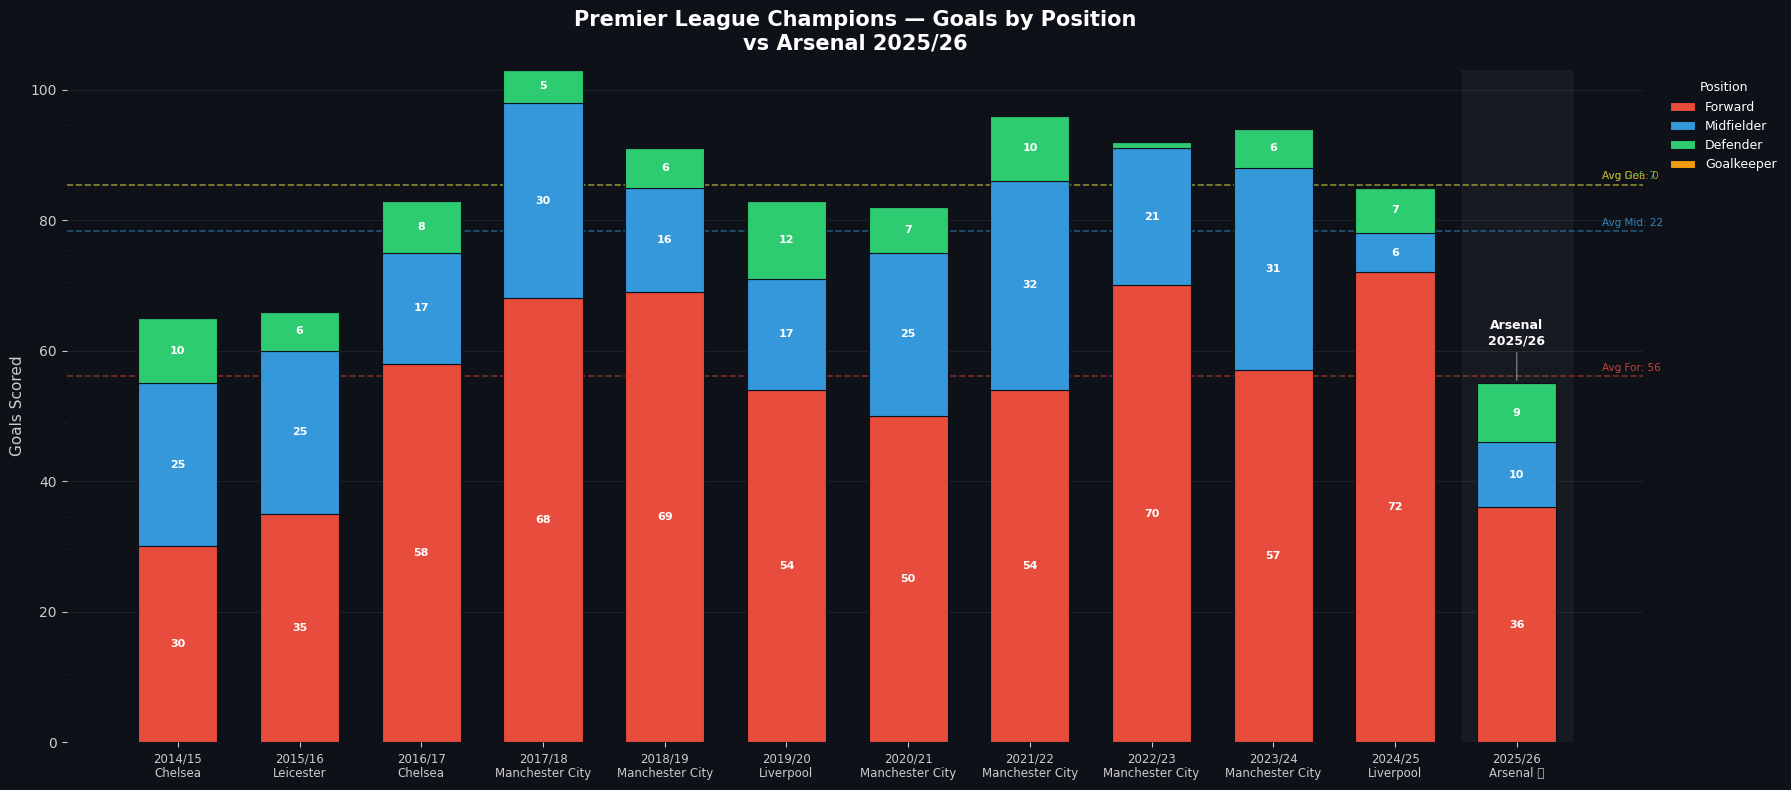

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

seasons    = list(pivot["season"])
x_pos      = range(len(seasons))
bar_width  = 0.65

# --- Stacked bars ---
bottom = [0] * len(pivot)
for pos in POS_ORDER:
    vals = pivot[pos].values
    bars = ax.bar(
        x_pos, vals, bottom=bottom,
        color=COLORS[pos], width=bar_width,
        label=pos, edgecolor="#0e1117", linewidth=0.8, zorder=3
    )
    # Label each segment if big enough
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 3:
            ax.text(
                i, b + v / 2, str(int(v)),
                ha="center", va="center",
                fontsize=8, color="white", fontweight="bold"
            )
    bottom = [b + v for b, v in zip(bottom, vals)]

# --- Champion average dashed lines ---
running = 0
for pos in POS_ORDER:
    running += avg[pos]
    ax.axhline(
        running, color=COLORS[pos], linestyle="--",
        linewidth=1.2, alpha=0.5, zorder=2
    )
    ax.text(
        len(seasons) - 0.3, running + 0.5,
        f"Avg {pos[:3]}: {avg[pos]:.0f}",
        color=COLORS[pos], fontsize=7.5, alpha=0.85, va="bottom"
    )

# --- Highlight Arsenal bar ---
arsenal_idx = seasons.index(arsenal_row["season"].values[0])
ax.axvspan(arsenal_idx - 0.45, arsenal_idx + 0.45,
           color="white", alpha=0.04, zorder=1)
ax.annotate(
    "Arsenal\n2025/26", xy=(arsenal_idx, bottom[arsenal_idx]),
    xytext=(arsenal_idx, bottom[arsenal_idx] + 6),
    ha="center", color="white", fontsize=9, fontweight="bold",
    arrowprops=dict(arrowstyle="-", color="white", alpha=0.4)
)

# --- Styling ---
ax.set_xticks(x_pos)
ax.set_xticklabels(seasons, color="#cccccc", fontsize=8.5)
ax.set_ylabel("Goals Scored", color="#cccccc", fontsize=11)
ax.set_title(
    "Premier League Champions — Goals by Position\nvs Arsenal 2025/26",
    color="white", fontsize=15, fontweight="bold", pad=15
)
ax.tick_params(colors="#cccccc")
ax.spines[["top","right","left","bottom"]].set_visible(False)
ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))
ax.grid(axis="y", color="#ffffff", alpha=0.07, linewidth=0.8, zorder=0)

legend = ax.legend(
    title="Position", title_fontsize=9,
    bbox_to_anchor=(1.01, 1), loc="upper left",
    framealpha=0, labelcolor="white", fontsize=9
)
legend.get_title().set_color("white")

plt.tight_layout()
plt.savefig("pl_champions_vs_arsenal.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

In [ ]:
# Check latest matchweek in 2025/26 Arsenal data
players_2025 = client.league(league="EPL").get_player_data(season="2025")

# Find Arsenal players and show their stats
arsenal_2025 = [p for p in players_2025 if p.get("team_title") == "Arsenal"]

# Print a summary
print(f"Arsenal players found: {len(arsenal_2025)}\n")
for p in sorted(arsenal_2025, key=lambda x: int(x.get("goals", 0)), reverse=True):
    print(f"{p['player_name']:<25} Pos: {p.get('position','?'):<5} Goals: {p.get('goals','0'):<4} Games: {p.get('games','0'):<4} Mins: {p.get('time','0')}")

Arsenal players found: 23

Viktor Gyokeres           Pos: F S   Goals: 14   Games: 34   Mins: 2237
Bukayo Saka               Pos: F M S Goals: 7    Games: 30   Mins: 2149
Leandro Trossard          Pos: F M S Goals: 6    Games: 30   Mins: 1936
Martín Zubimendi          Pos: M S   Goals: 5    Games: 36   Mins: 2949
Mikel Merino              Pos: F M S Goals: 4    Games: 21   Mins: 977
Declan Rice               Pos: D M S Goals: 4    Games: 35   Mins: 3021
Gabriel                   Pos: D S   Goals: 3    Games: 30   Mins: 2617
Jurriën Timber            Pos: D S   Goals: 3    Games: 30   Mins: 2475
Gabriel Jesus             Pos: F S   Goals: 2    Games: 13   Mins: 317
Martin Odegaard           Pos: M S   Goals: 1    Games: 23   Mins: 1257
Kai Havertz               Pos: F M S Goals: 1    Games: 10   Mins: 466
William Saliba            Pos: D S   Goals: 1    Games: 30   Mins: 2519
Gabriel Martinelli        Pos: F M S Goals: 1    Games: 28   Mins: 934
Riccardo Calafiori        Pos: D S   Goal

In [ ]:
# Cell 7 — Build metrics from existing df (no re-fetch needed)

ATTACKING_METRICS = ["xG", "npxG", "shots", "key_passes", "xA", "xGChain"]
METRIC_LABELS     = ["xG", "Non-Pen xG", "Shots", "Key Passes", "xA", "xG Chain"]

for m in ATTACKING_METRICS:
    df[m] = pd.to_numeric(df[m], errors="coerce").fillna(0)

champ_df    = df[df["team"] != "Arsenal"]
arsenal_df  = df[df["team"] == "Arsenal"]

champ_season_totals = champ_df.groupby("season")[ATTACKING_METRICS].sum()
champ_avg           = champ_season_totals.mean()
arsenal_totals      = arsenal_df[ATTACKING_METRICS].sum()

print("Champion averages:")
for m in ATTACKING_METRICS:
    print(f"  {m}: {champ_avg[m]:.1f}")

print("\nArsenal 2025/26 totals:")
for m in ATTACKING_METRICS:
    print(f"  {m}: {arsenal_totals[m]:.1f}")

Champion averages:
  xG: 82.5
  npxG: 76.5
  shots: 619.0
  key_passes: 479.3
  xA: 60.8
  xGChain: 266.2

Arsenal 2025/26 totals:
  xG: 69.7
  npxG: 66.7
  shots: 469.0
  key_passes: 369.0
  xA: 48.7
  xGChain: 179.0


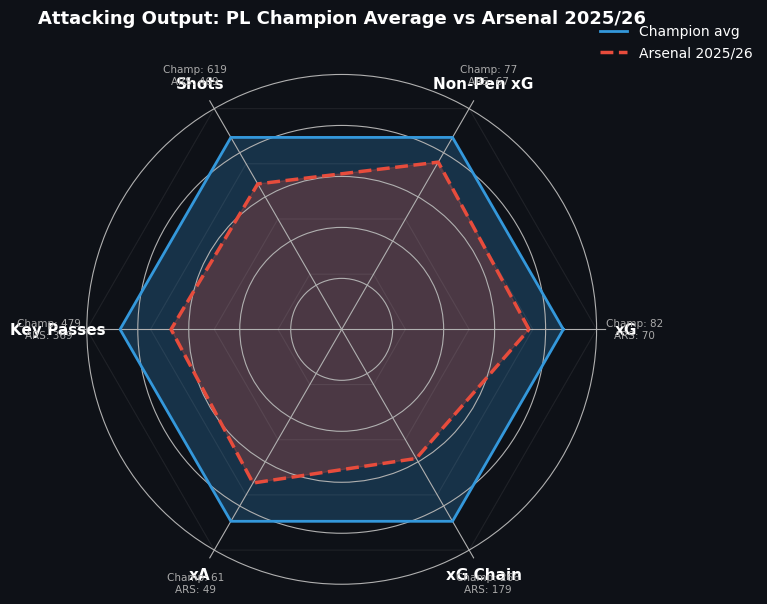


--- Summary Table ---
    Metric Champion Avg Arsenal 25/26 Diff %
        xG         82.5          69.7 -15.5%
Non-Pen xG         76.5          66.7 -12.9%
     Shots        619.0         469.0 -24.2%
Key Passes        479.3         369.0 -23.0%
        xA         60.8          48.7 -19.9%
  xG Chain        266.2         179.0 -32.7%


In [ ]:
# Cell 8 — Fixed radar chart

N = len(ATTACKING_METRICS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# Normalise against the max across both
max_vals = [max(champ_avg[m], arsenal_totals[m]) * 1.15 for m in ATTACKING_METRICS]

def to_radar(values, max_vals):
    return [(v / m) * 100 for v, m in zip(values, max_vals)]

champ_vals   = to_radar([champ_avg[m]      for m in ATTACKING_METRICS], max_vals)
arsenal_vals = to_radar([arsenal_totals[m] for m in ATTACKING_METRICS], max_vals)

# Close the loop by appending the first value AND first angle
angles_closed       = angles + [angles[0]]
champ_vals_closed   = champ_vals + [champ_vals[0]]
arsenal_vals_closed = arsenal_vals + [arsenal_vals[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

# Grid rings
for r in [25, 50, 75, 100]:
    ax.plot(angles_closed, [r]*(N+1), color="white", alpha=0.07, linewidth=0.8)

# Champion average
ax.fill(angles, champ_vals, color="#3498db", alpha=0.25)
ax.plot(angles_closed, champ_vals_closed, color="#3498db", linewidth=2, label="Champion avg")

# Arsenal
ax.fill(angles, arsenal_vals, color="#e74c3c", alpha=0.25)
ax.plot(angles_closed, arsenal_vals_closed, color="#e74c3c", linewidth=2.5,
        linestyle="--", label="Arsenal 2025/26")

# Labels
ax.set_xticks(angles)
ax.set_xticklabels(METRIC_LABELS, color="white", fontsize=11, fontweight="bold")
ax.set_yticklabels([])
ax.spines["polar"].set_visible(False)

# Print actual numbers under each label
for angle, m in zip(angles, ATTACKING_METRICS):
    ax.text(angle, 115,
            f"Champ: {champ_avg[m]:.0f}\nARS: {arsenal_totals[m]:.0f}",
            ha="center", va="center", color="#aaaaaa", fontsize=7.5)

ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1),
          framealpha=0, labelcolor="white", fontsize=10)
ax.set_title("Attacking Output: PL Champion Average vs Arsenal 2025/26",
             color="white", fontsize=13, fontweight="bold", pad=30)

plt.tight_layout()
plt.savefig("arsenal_radar_vs_champions.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# Summary table
print("\n--- Summary Table ---")
summary = pd.DataFrame({
    "Metric":        METRIC_LABELS,
    "Champion Avg":  [f"{champ_avg[m]:.1f}"      for m in ATTACKING_METRICS],
    "Arsenal 25/26": [f"{arsenal_totals[m]:.1f}"  for m in ATTACKING_METRICS],
    "Diff %":        [f"{((arsenal_totals[m]-champ_avg[m])/champ_avg[m])*100:+.1f}%"
                      for m in ATTACKING_METRICS]
})
print(summary.to_string(index=False))

In [ ]:
# Cell 9 — Fixed with correct field structure

def fetch_team_goal_situations(team_name, season, label):
    matches = client.team(team=team_name.replace(" ", "_")).get_match_data(season=season)

    situation_counts = {}

    for match in matches:
        match_id = match["id"]
        h_title  = match["h"]["title"]
        a_title  = match["a"]["title"]

        # Which side is our team?
        if h_title == team_name:
            our_side = "h"
        elif a_title == team_name:
            our_side = "a"
        else:
            continue

        try:
            shot_data = client.match(match=match_id).get_shot_data()
            shots = shot_data.get(our_side, [])

            for shot in shots:
                if shot.get("result") == "Goal":
                    sit = shot.get("situation", "Other")
                    situation_counts[sit] = situation_counts.get(sit, 0) + 1

            time.sleep(1)
        except Exception as e:
            print(f"  Skipping match {match_id}: {e}")

    print(f"  ✓ {team_name} {label}: {sum(situation_counts.values())} goals — {situation_counts}")
    return {"season": label, "team": team_name, **situation_counts}

In [ ]:
# Cell 10 — Run for all champions + Arsenal
# Takes ~10-15 mins, grab a coffee

rows = []

for season, champion in champions.items():
    label = f"{season}/{str(int(season)+1)[2:]}"
    print(f"Fetching {label} — {champion}...")
    rows.append(fetch_team_goal_situations(champion, season, label))
    time.sleep(2)

print("\nFetching Arsenal 2025/26...")
rows.append(fetch_team_goal_situations("Arsenal", "2025", "2025/26"))

df_sit = pd.DataFrame(rows).fillna(0)
print(df_sit)

Fetching 2014/15 — Chelsea...
  ✓ Chelsea 2014/15: 72 goals — {'OpenPlay': 53, 'FromCorner': 10, 'Penalty': 4, 'DirectFreekick': 1, 'SetPiece': 4}
Fetching 2015/16 — Leicester...
  ✓ Leicester 2015/16: 67 goals — {'SetPiece': 6, 'OpenPlay': 46, 'Penalty': 10, 'FromCorner': 5}
Fetching 2016/17 — Chelsea...
  ✓ Chelsea 2016/17: 83 goals — {'Penalty': 2, 'OpenPlay': 59, 'FromCorner': 13, 'SetPiece': 6, 'DirectFreekick': 3}
Fetching 2017/18 — Manchester City...
  ✓ Manchester City 2017/18: 103 goals — {'OpenPlay': 82, 'SetPiece': 4, 'FromCorner': 10, 'Penalty': 6, 'DirectFreekick': 1}
Fetching 2018/19 — Manchester City...
  ✓ Manchester City 2018/19: 91 goals — {'OpenPlay': 77, 'DirectFreekick': 2, 'SetPiece': 4, 'FromCorner': 5, 'Penalty': 3}
Fetching 2019/20 — Liverpool...
  ✓ Liverpool 2019/20: 83 goals — {'OpenPlay': 61, 'FromCorner': 11, 'Penalty': 5, 'SetPiece': 4, 'DirectFreekick': 2}
Fetching 2020/21 — Manchester City...
  ✓ Manchester City 2020/21: 82 goals — {'Penalty': 5, 'OpenP

In [ ]:
# Diagnostic — inspect one match's raw structure
test_matches = client.team(team="Chelsea").get_match_data(season="2014")
test_match = test_matches[0]

print("Match keys:", test_match.keys())
print("Full match record:", test_match)
print()

# Now inspect the shot data for that match
test_shots = client.match(match=test_match["id"]).get_shot_data()
print("Shot data keys:", test_shots.keys())
print("Type of 'h':", type(test_shots["h"]))
print()
# Print first shot to see its fields
h_shots = test_shots["h"]
if isinstance(h_shots, list):
    print("First shot (list):", h_shots[0] if h_shots else "empty")
elif isinstance(h_shots, dict):
    first_key = list(h_shots.keys())[0]
    print("First shot (dict):", h_shots[first_key])

Match keys: dict_keys(['id', 'isResult', 'side', 'h', 'a', 'goals', 'xG', 'datetime', 'forecast', 'result'])
Full match record: {'id': '4758', 'isResult': True, 'side': 'a', 'h': {'id': '92', 'title': 'Burnley', 'short_title': 'BUR'}, 'a': {'id': '80', 'title': 'Chelsea', 'short_title': 'CHE'}, 'goals': {'h': '1', 'a': '3'}, 'xG': {'h': '0.371141', 'a': '2.12996'}, 'datetime': '2014-08-18 20:00:00', 'forecast': {'w': 0.05237334876215158, 'd': 0.16080519902230478, 'l': 0.7868214433948378}, 'result': 'w'}

Shot data keys: dict_keys(['h', 'a'])
Type of 'h': <class 'list'>

First shot (list): {'id': '14442', 'minute': '0', 'result': 'MissedShots', 'X': '0.8030000305175782', 'Y': '0.26', 'xG': '0.0113172996789217', 'player': 'Lukas Jutkiewicz', 'h_a': 'h', 'player_id': '1664', 'situation': 'OpenPlay', 'season': '2014', 'shotType': 'LeftFoot', 'match_id': '4758', 'h_team': 'Burnley', 'a_team': 'Chelsea', 'h_goals': '1', 'a_goals': '3', 'date': '2014-08-18 20:00:00', 'player_assisted': None, 

/tmp/ipykernel_43344/2157289370.py:82: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_43344/2157289370.py:83: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  plt.savefig("pl_champions_goal_situations.png", dpi=150,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9917 (\N{SOCCER BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


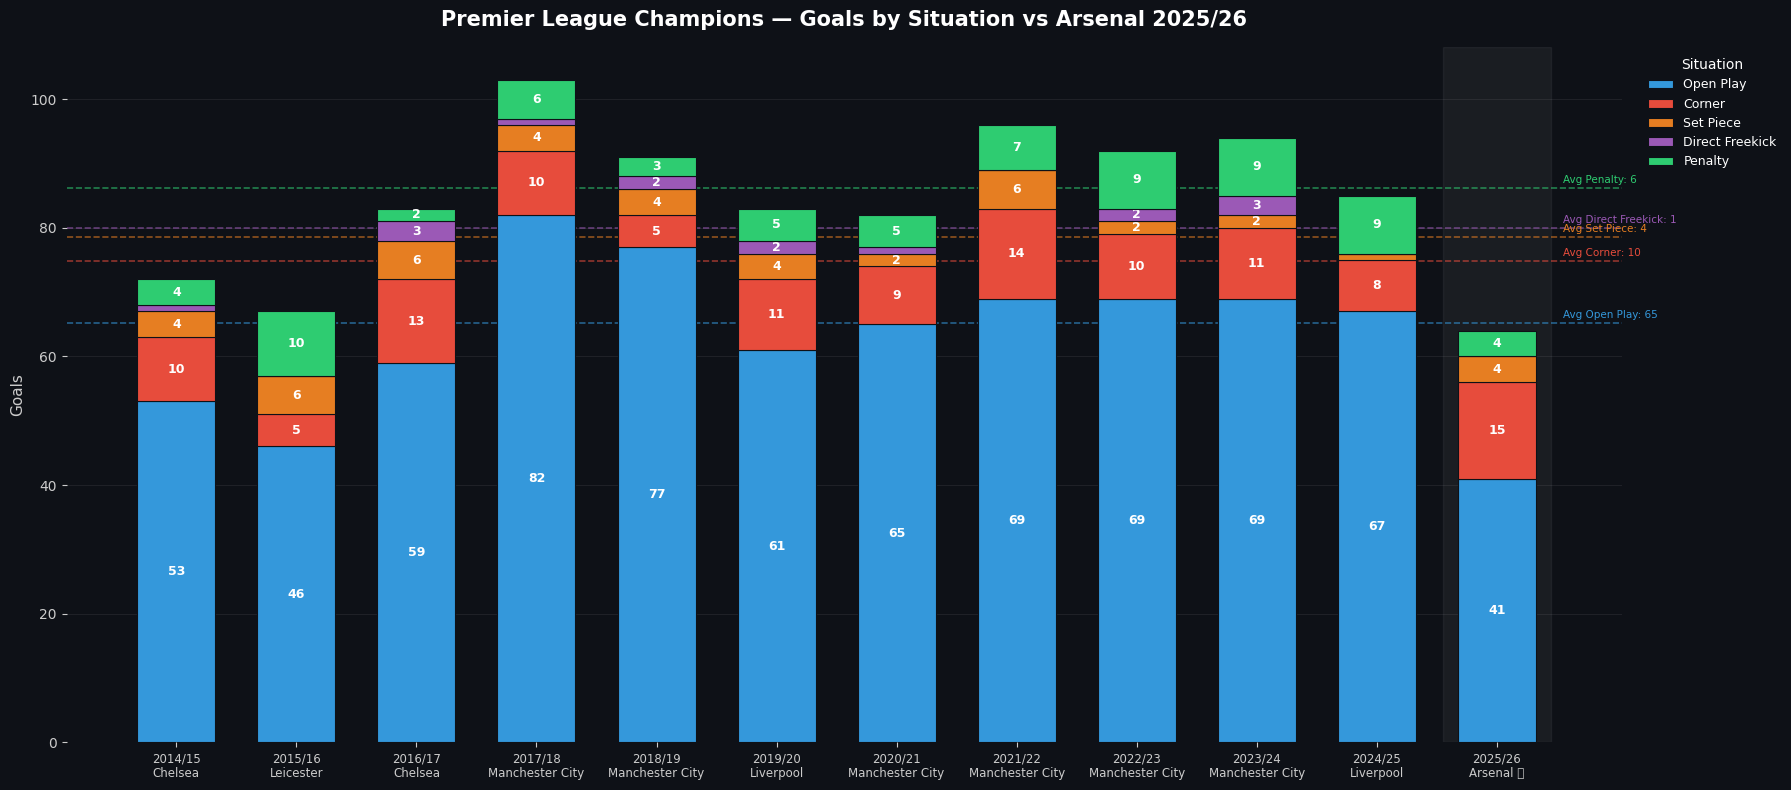

In [ ]:
# Cell 11 — Remap understat's situation labels and plot

# Understat returns these exact strings
SITUATION_MAP = {
    "OpenPlay":       "Open Play",
    "FromCorner":     "Corner",
    "SetPiece":       "Set Piece",
    "DirectFreekick": "Direct Freekick",
    "Penalty":        "Penalty",
}

df_sit = df_sit.rename(columns=SITUATION_MAP)

SIT_ORDER  = ["Open Play", "Corner", "Set Piece", "Direct Freekick", "Penalty"]
SIT_COLORS = {
    "Open Play":       "#3498db",
    "Corner":          "#e74c3c",
    "Set Piece":       "#e67e22",
    "Direct Freekick": "#9b59b6",
    "Penalty":         "#2ecc71",
}

# Ensure all columns exist
for s in SIT_ORDER:
    if s not in df_sit.columns:
        df_sit[s] = 0

# Champion average (exclude Arsenal)
champ_df  = df_sit[df_sit["team"] != "Arsenal"]
champ_avg = {s: champ_df[s].mean() for s in SIT_ORDER}

# Labels for x axis
df_sit["label"] = df_sit["season"] + "\n" + df_sit["team"].apply(
    lambda t: "Arsenal ⚽" if t == "Arsenal" else t
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor("#0e1117")
ax.set_facecolor("#0e1117")

x   = range(len(df_sit))
bot = [0.0] * len(df_sit)

for sit in SIT_ORDER:
    vals = df_sit[sit].values.astype(float)
    ax.bar(x, vals, bottom=bot, color=SIT_COLORS[sit],
           width=0.65, label=sit, edgecolor="#0e1117", linewidth=0.8, zorder=3)
    for i, (v, b) in enumerate(zip(vals, bot)):
        if v >= 2:
            ax.text(i, b + v/2, str(int(v)), ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bot = [b + v for b, v in zip(bot, vals)]

# Champion average dashed lines
running = 0.0
for sit in SIT_ORDER:
    running += champ_avg[sit]
    ax.axhline(running, color=SIT_COLORS[sit], linestyle="--",
               linewidth=1.2, alpha=0.6, zorder=2)
    ax.text(len(df_sit) - 0.45, running + 0.5,
            f"Avg {sit}: {champ_avg[sit]:.0f}",
            color=SIT_COLORS[sit], fontsize=7.5, va="bottom")

# Highlight Arsenal column
ars_idx = list(df_sit["team"]).index("Arsenal")
ax.axvspan(ars_idx - 0.45, ars_idx + 0.45, color="white", alpha=0.05, zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(df_sit["label"], color="#cccccc", fontsize=8.5)
ax.set_ylabel("Goals", color="#cccccc", fontsize=11)
ax.set_title("Premier League Champions — Goals by Situation vs Arsenal 2025/26",
             color="white", fontsize=15, fontweight="bold", pad=15)
ax.tick_params(colors="#cccccc")
ax.spines[["top","right","left","bottom"]].set_visible(False)
ax.grid(axis="y", color="#ffffff", alpha=0.07, linewidth=0.8)

legend = ax.legend(title="Situation", bbox_to_anchor=(1.01, 1), loc="upper left",
                   framealpha=0, labelcolor="white", fontsize=9)
legend.get_title().set_color("white")

plt.tight_layout()
plt.savefig("pl_champions_goal_situations.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()